Dataset loaded successfully
Original shape: (16969, 10)

Cleaned column names:
['age', 'blood_glucose_level_bgl', 'diastolic_blood_pressure', 'systolic_blood_pressure', 'heart_rate', 'body_temperature', 'spo2', 'sweating_y_n', 'shivering_y_n', 'diabetic_nondiabetic_d_n']

Shape after removing empty rows and duplicates: (16701, 10)

Updated Target Distribution:
hypoglycemia_status
0    11554
1     5147
Name: count, dtype: int64

Updated Target Percentage:
hypoglycemia_status
0    69.181486
1    30.818514
Name: proportion, dtype: float64


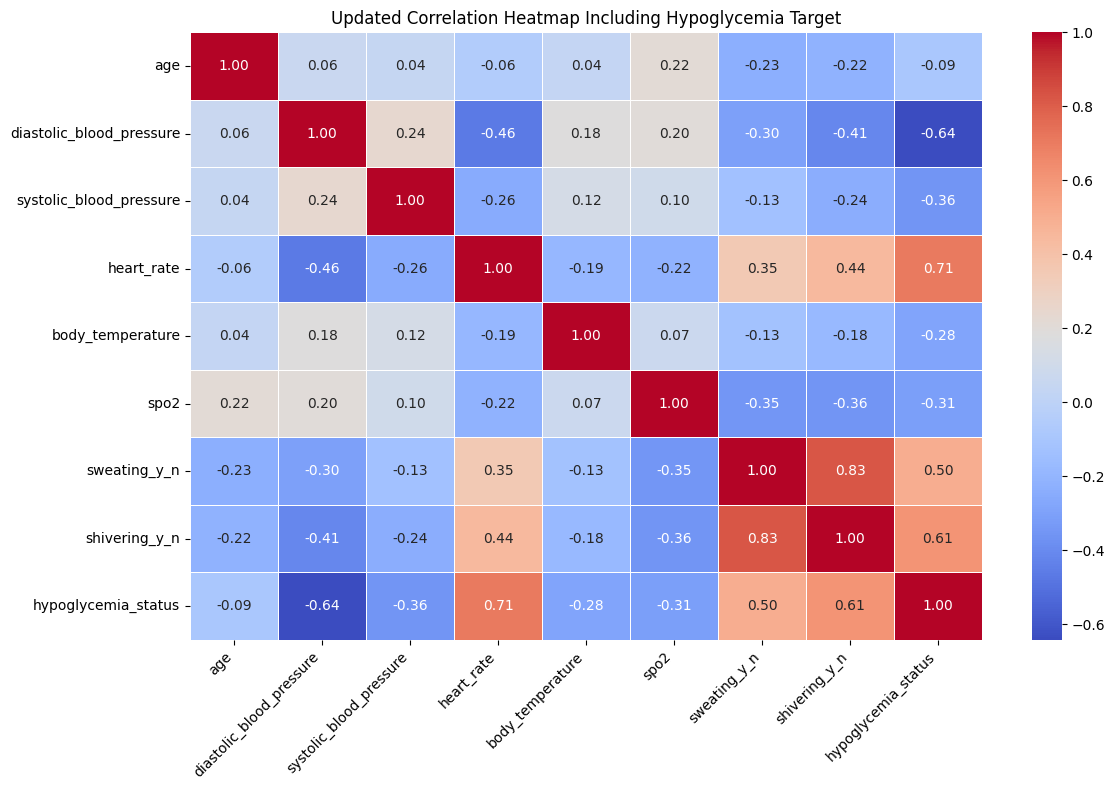


Correlation with hypoglycemia_status:
heart_rate                  0.705923
shivering_y_n               0.614697
sweating_y_n                0.504082
age                        -0.093572
body_temperature           -0.283379
spo2                       -0.309234
systolic_blood_pressure    -0.357252
diastolic_blood_pressure   -0.642064
Name: hypoglycemia_status, dtype: float64


In [3]:
# ============================================================
# LOAD DATASET + CREATE UPDATED TARGET + HEATMAP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ------------------------------------------------------------
# 1. LOAD EXCEL DATASET
# ------------------------------------------------------------

file_path = (
    "Dataset for People for their Blood Glucose Level with their "
    "Superficial body feature readings..xlsx"
)

# Real column names start from row 3, so header=2
df = pd.read_excel(file_path, header=2)

print("Dataset loaded successfully")
print("Original shape:", df.shape)

# ------------------------------------------------------------
# 2. CLEAN COLUMN NAMES
# ------------------------------------------------------------

def clean_column_name(col):
    col = str(col).strip().lower()
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = col.strip("_")
    return col

df.columns = [clean_column_name(col) for col in df.columns]

print("\nCleaned column names:")
print(df.columns.tolist())

# ------------------------------------------------------------
# 3. REMOVE EMPTY ROWS AND DUPLICATES
# ------------------------------------------------------------

df = df.dropna(how="all")
df = df.drop_duplicates()

print("\nShape after removing empty rows and duplicates:", df.shape)

# ------------------------------------------------------------
# 4. CREATE NEW TARGET COLUMN FROM BLOOD GLUCOSE LEVEL
# ------------------------------------------------------------

# 1 = Hypoglycemia, 0 = Not hypoglycemia
# Hypoglycemia is created when Blood Glucose Level is below 70

df["hypoglycemia_status"] = np.where(
    df["blood_glucose_level_bgl"] < 70,
    1,
    0
)

print("\nUpdated Target Distribution:")
print(df["hypoglycemia_status"].value_counts())

print("\nUpdated Target Percentage:")
print(df["hypoglycemia_status"].value_counts(normalize=True) * 100)

# ------------------------------------------------------------
# 5. PREPARE DATA FOR UPDATED HEATMAP
# ------------------------------------------------------------

# Remove old target because it was weak
# Remove BGL because new target is created from BGL
# Keeping BGL would cause data leakage

heatmap_df = df.drop(
    columns=[
        "blood_glucose_level_bgl",
        "diabetic_nondiabetic_d_n"
    ],
    errors="ignore"
)

# Convert any remaining categorical columns to numbers
for col in heatmap_df.columns:
    if heatmap_df[col].dtype == "object":
        heatmap_df[col] = heatmap_df[col].astype("category").cat.codes

# Correlation matrix
corr_matrix = heatmap_df.corr(numeric_only=True)

# ------------------------------------------------------------
# 6. PLOT UPDATED CORRELATION HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Updated Correlation Heatmap Including Hypoglycemia Target")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. CORRELATION WITH NEW TARGET
# ------------------------------------------------------------

print("\nCorrelation with hypoglycemia_status:")
print(
    corr_matrix["hypoglycemia_status"]
    .drop("hypoglycemia_status")
    .sort_values(ascending=False)
)